<a href="https://colab.research.google.com/github/lomnitzs-maker/sophia/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Sophia Lomnitz
*Neur 265*

**3/4**

In [27]:
# importing necessary material
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [28]:
# importing file as a pandas data frame
url = "https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded_v2.csv"
patch_seq = pd.read_csv(url)



Text(0.5, 1.0, 'Value counts of Markers')

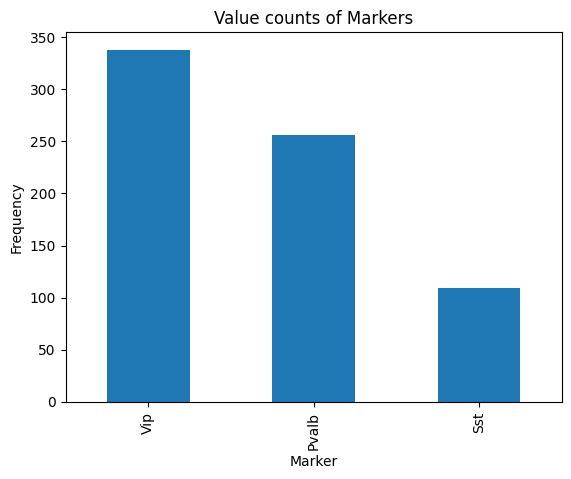

In [29]:
# Making a bar graph that displays the value counts from the Marker column of patch_seq
patch_seq['Marker'].value_counts().plot(kind='bar')
plt.xlabel("Marker")
plt.ylabel("Frequency")
plt.title("Value counts of Markers")

Text(0.5, 1.0, 'Value counts of Markers')

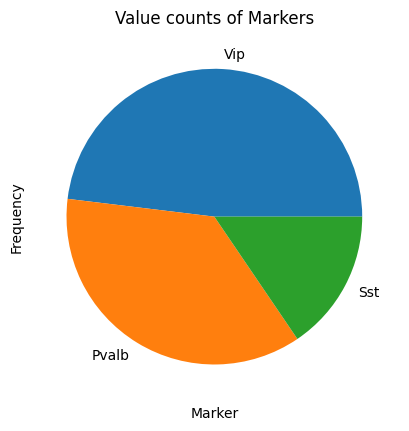

In [ ]:
# repeating step four but making a pie chart
patch_seq['Marker'].value_counts().plot(kind='pie')
plt.xlabel("Marker")
plt.ylabel("Frequency")
plt.title("Value counts of Markers")

Text(0, 0.5, 'Fast Trough')

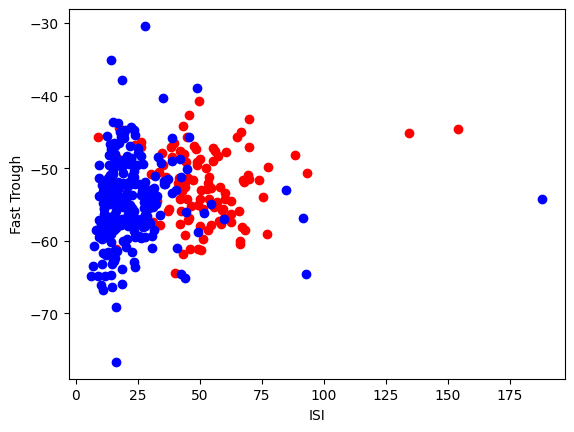

In [ ]:
# using a for loop to make a scatter plot of ISI and Fast_Trough values, sst neurons are red and pvalb neurons are blue

ISI = patch_seq['ISI']
Fast_Trough = patch_seq['Fast_Trough']
Marker = patch_seq['Marker']


for i in range(len(patch_seq)):
  x = ISI[i]
  y= Fast_Trough[i]
  if Marker[i] == 'Sst':
    plt.scatter(x,y, color="red")

  elif Marker[i]=='Pvalb':
    plt.scatter(x,y, color="blue")

plt.xlabel("ISI")
plt.ylabel("Fast Trough")




In [ ]:
# making a fucntion that executes the code in step 6 when called
def patchScatter():
  """
  execute all code in code cell above/step 6
  """
  ISI = patch_seq['ISI']
  Fast_Trough = patch_seq['Fast_Trough']
  Marker = patch_seq['Marker']


  for i in range(len(patch_seq)):
    x = ISI[i]
    y= Fast_Trough[i]
    if Marker[i] == 'Sst':
      plt.scatter(x,y, color="red")

    elif Marker[i]=='Pvalb':
      plt.scatter(x,y, color="blue")

  plt.xlabel("ISI")
  plt.ylabel("Fast Trough")
  plt.show()

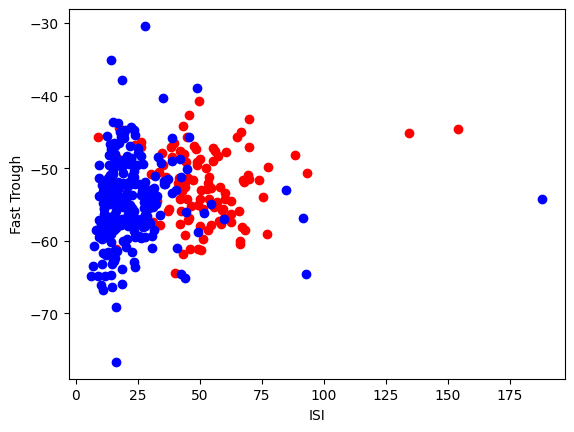

In [ ]:
# testing to make sure my function works
patchScatter()

In [ ]:
# returning the mean, standard deviation, and range of the "Fast_Trough" column for "Sst" neurons and "Pvalb" neurons
stats = patch_seq.groupby('Marker')['Fast_Trough'].describe().loc[['Pvalb','Sst']]
stats[['mean','std','min','max']]



,mean,std,min,max
Marker,,,,
Pvalb,-54.548074,5.870670,-76.687508,-30.406252
Sst,-52.514968,4.958103,-64.375008,-40.781254


The Pvalb mean is more negative than the Sst mean. The Pvalb mean is -54.55, whereas the Sst mean is -52.51. This means Pvalb neurons have a more negative aftershoot following an action potential.

In [18]:
# returning the skewness of the "Fast_Trough" column for "Sst" neurons and "Pvalb" neurons
#stats = patch_seq.groupby('Marker')['Fast_Trough'].describe().loc[['Pvalb','Sst']]
patch_seq.groupby('Marker')['Fast_Trough'].skew().loc[['Pvalb', 'Sst']]

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


Based on my skewness test, since both numbers are less than 0.5, there is not a skewed distribution for either neuron type

In [19]:
# repeating step 10 for ISI
patch_seq.groupby('Marker')['ISI'].skew().loc[['Pvalb', 'Sst']]

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


The results of my skewness test for the ISI column indicate there is a skew in both types of neuron data

In [30]:
# running a ttest to see if my Fast_Trough and ISI values significantly differ between Sst and Pvalb neurons
Sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
Pvalb_neurons = patch_seq[patch_seq['Marker']== 'Pvalb']
stats.ttest_ind(Sst_neurons['Fast_Trough'], Pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

According to my t-test, the undershoot voltage does signficantly differ between the two groups. This is because 0.001<0.05.

In [40]:
# repeating step 14 for ISI
Sst = Sst_neurons['ISI'].dropna()
Pvalb = Pvalb_neurons['ISI'].dropna()
stats.ttest_ind(Sst,Pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

This t-test indicates that there is no significant difference in ISI values for Sst and Pvalb neurons. This is because 2.69 > 0.05.